Dataset:
   Dancer_ID  Age  Experience_Years  Practice_Hours  Practice_Days  \
0          1   22               2.4            11.7              2   
1          2   19               0.9             4.3              3   
2          3   28               3.6            11.2              6   
3          4   26               4.2             6.1              2   
4          5   23               3.1             9.9              7   

   Warmup_Minutes  Sleep_Hours  Energy_Level Practice_Intensity  \
0              13          5.1             3                Low   
1              16          8.3             3             Medium   
2              25          6.1             4             Medium   
3               5          5.5             9               High   
4              30          7.8             2                Low   

   New_Steps_Learned  Mistakes_Per_Session     Mood  Previous_Score  \
0                 15                    15    Tired            91.4   
1                 13     

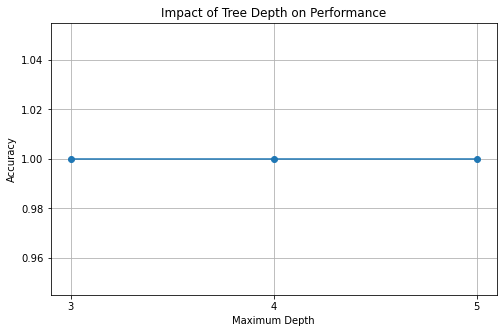

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


# -----------------------------------------
# Load Dataset
# -----------------------------------------

df = pd.read_csv("dancing_performance_dataset.csv")

print("Dataset:")
print(df.head())


# -----------------------------------------
# Check Missing Values
# -----------------------------------------

print("\nMissing values:")
print(df.isnull().sum())


# -----------------------------------------
# Replace Infinity Values
# -----------------------------------------

df = df.replace([float("inf"), float("-inf")], pd.NA)


# -----------------------------------------
# Convert Performance Score into Pass/Fail
# -----------------------------------------

df["Performance"] = df["Performance_Score"].apply(
    lambda x: "Pass" if x >= 50 else "Fail"
)


# -----------------------------------------
# Separate Features and Target
# -----------------------------------------

X = df.drop(
    ["Performance_Score", "Performance"],
    axis=1
)

y = df["Performance"]


# -----------------------------------------
# Fill Missing Values
# -----------------------------------------

# Fill numerical columns with median
numerical_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns

for column in numerical_columns:
    X[column] = X[column].fillna(X[column].median())


# Fill categorical columns with most common value
categorical_columns = X.select_dtypes(
    include=["object"]
).columns

for column in categorical_columns:
    X[column] = X[column].fillna(X[column].mode()[0])


# -----------------------------------------
# Convert Categorical Data into Numbers
# -----------------------------------------

X = pd.get_dummies(X)


# -----------------------------------------
# Split Dataset
# -----------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# -----------------------------------------
# Try Different Tree Depths
# -----------------------------------------

depths = [3, 4, 5]
accuracies = []

for depth in depths:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    accuracies.append(accuracy)

    print("\nMax Depth:", depth)
    print("Accuracy:", accuracy)
    print("------------------------")


# -----------------------------------------
# Comparative Analysis
# -----------------------------------------

results = pd.DataFrame({
    "Max Depth": depths,
    "Accuracy": accuracies
})

print("\nComparison:")
print(results)


# -----------------------------------------
# Plot Comparison
# -----------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    depths,
    accuracies,
    marker="o"
)

plt.xlabel("Maximum Depth")
plt.ylabel("Accuracy")
plt.title("Impact of Tree Depth on Performance")

plt.xticks(depths)
plt.grid()

plt.show()